# HOMEWORK 1

You will build two collages:
1. a 2×2 collage of the image with its colour channels reordered (RGB, RBG, GRB, BGR);
2. a collage of the image flipped horizontally and vertically.

***********************
Image BRG shape (rows, cols, channels):  (350, 625, 3)
Top left pixel info:  [176 135  80]
***********************

***********************
Image RGB shape (rows, cols, channels):  (350, 625, 3)
Top left pixel info:  [ 80 135 176]
***********************

***********************
Image RGB shape (rows, cols, channels):  (350, 625, 3)
Top left pixel info:  [ 80 135 176]
***********************

***********************
Image GRAY shape (rows, cols, channels):  (350, 625)
Top left pixel info:  123
***********************



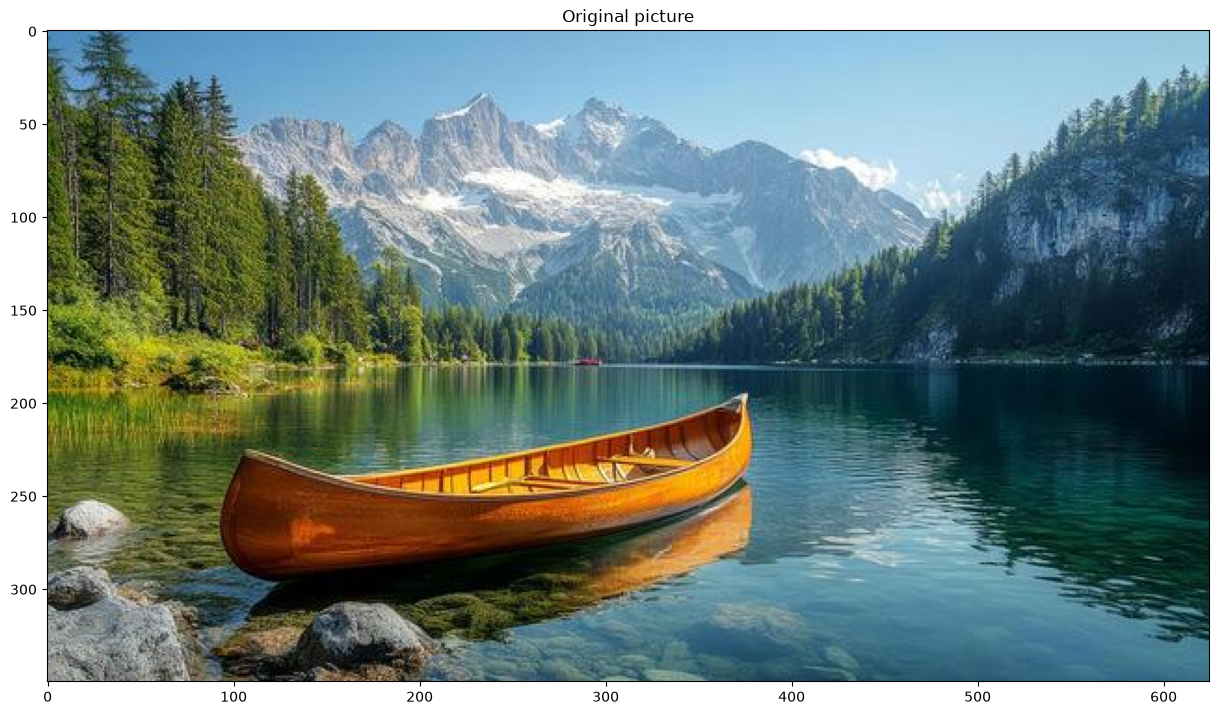

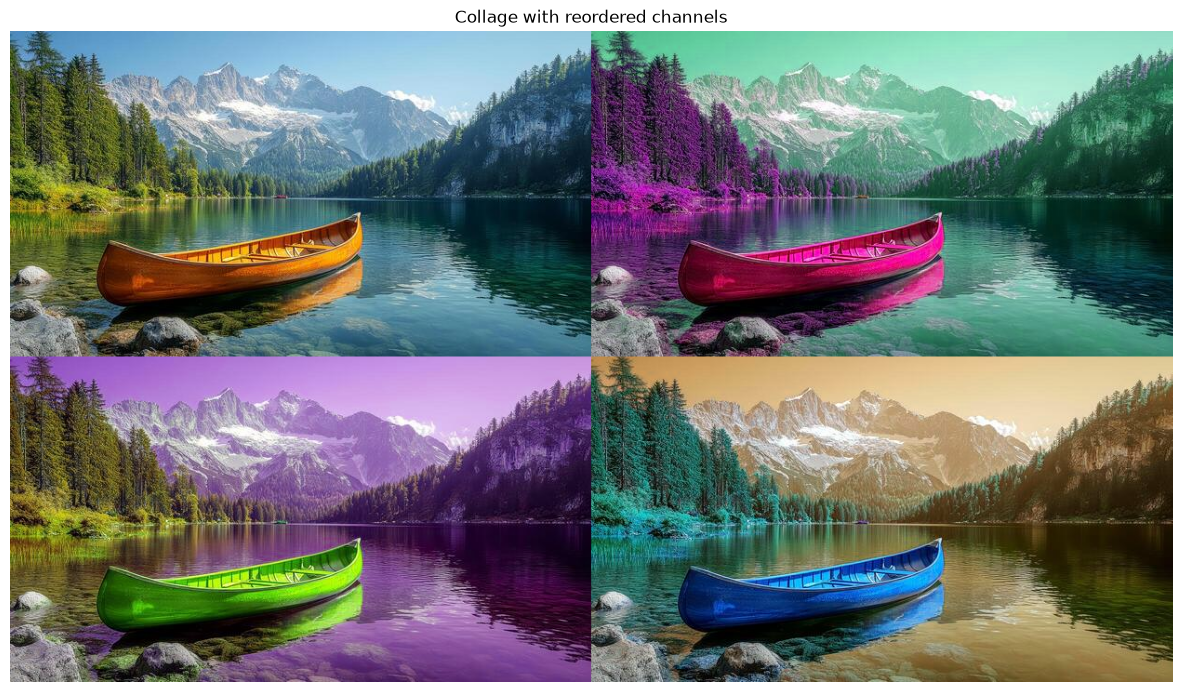

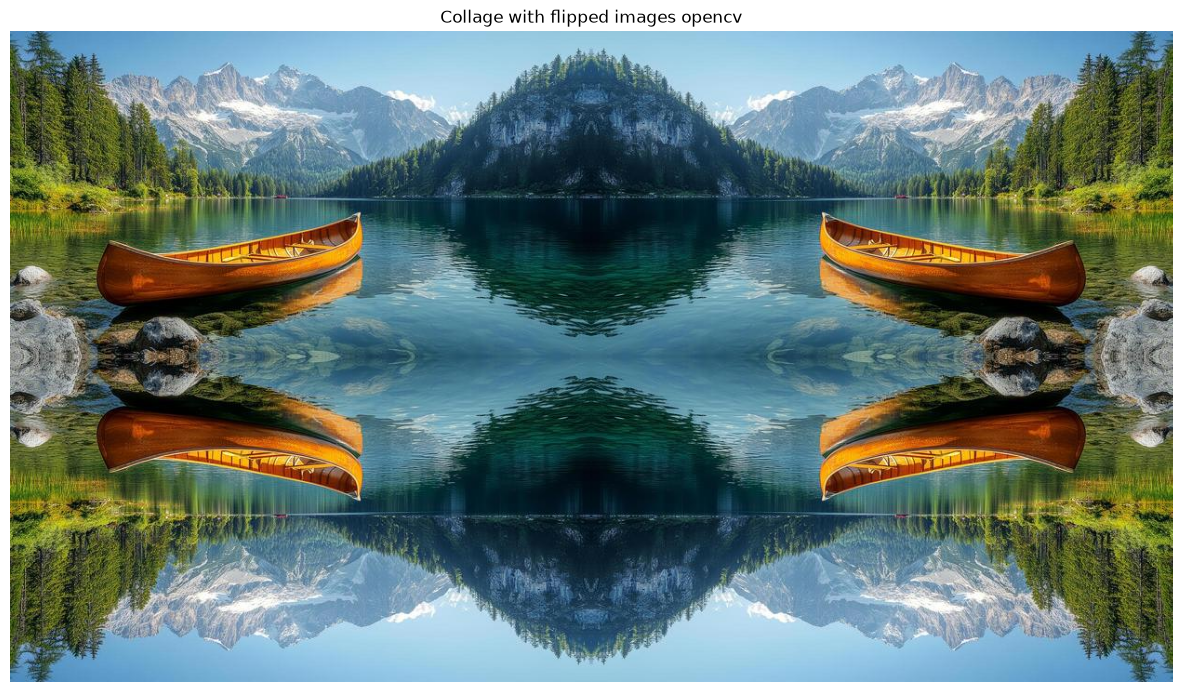

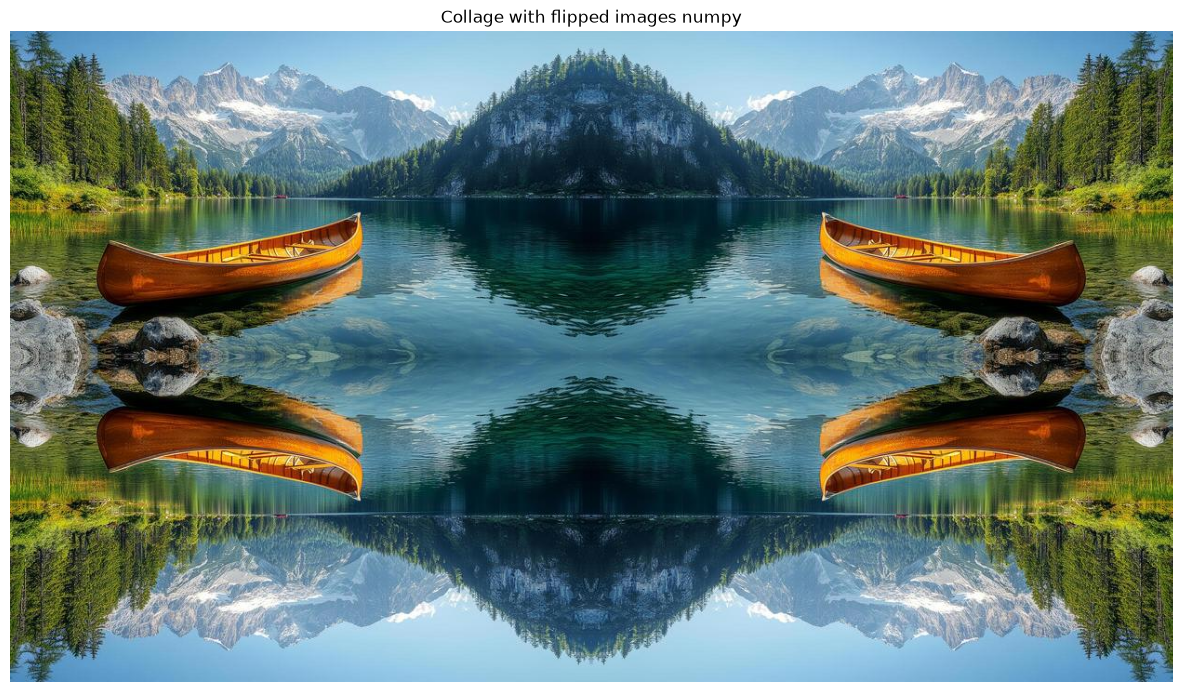

In [98]:
import cv2
import sys
import numpy as np
from matplotlib import pyplot as plt

def main(args):
    img = cv2.imread('../data/example_2.jpg')
    plt.rcParams['figure.figsize'] = [15, 10]
    
    img_rgb = brg2rgb_opencv(img);
    img_rgb_slice = brg2rgb_slicing(img);
    img_gray = rgb2gray_opencv(img_rgb);

    print_image_parameters(img, "BRG")
    print_image_parameters(img_rgb, "RGB")
    print_image_parameters(img_rgb_slice, "RGB")
    print_image_parameters(img_gray, "GRAY")

    display_image(img_rgb, "Original picture")

    collage2x2 = collage_with_reordered_channels(img_rgb)
    display_image(collage2x2, "Collage with reordered channels", False)

    collage_of_flipped_images = collage_with_flipped_images_open_cv(img_rgb)
    display_image(collage_of_flipped_images, "Collage with flipped images opencv", False)

    collage_of_flipped_images_np = collage_with_flipped_images_np(img_rgb)
    display_image(collage_of_flipped_images, "Collage with flipped images numpy", False)


# be sure the img is BRG for consistent results
def brg2rgb_opencv(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# be sure the img is RGB for consistent results
def rgb2gray_opencv(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# be sure the img is RGB for consistent results
def brg2rgb_slicing(img):
    return img[:, :, ::-1]

def print_image_parameters(img, color_space_name = ''):
    print('***********************')
    print(f'Image {color_space_name} shape (rows, cols, channels): ', img.shape)
    print(f'Top left pixel info: ', img[0, 0])
    print('***********************\n')

def display_image(img, title="", show_axis = True):
    plt.figure()
    plt.imshow(img)
    plt.title(title)
    
    if show_axis == False:
        plt.axis('off')

def collage_with_reordered_channels(img):
   # Split the image into the three colour channels 
    red, green, blue = cv2.split(img)

    # Compose the image in the RGB colour space
    img1 = cv2.merge([red, green, blue])

    # Compose the image in the RBG colour space
    img2 = cv2.merge([red, blue, green])

    # Compose the image in the GRB colour space
    img3 = cv2.merge([green, red, blue])

    # Compose the image in the BGR colour space
    img4 = cv2.merge([blue, green, red])

    # Create the collage
    out1 = np.hstack([img1, img2])
    out2 = np.hstack([img3, img4])
    out = np.vstack([out1, out2])

    return out

def collage_with_flipped_images_open_cv(img):

    # flip image horizontally
    img1 = flip_image_opencv(img, 1)

    # flip image vertically
    img2 = flip_image_opencv(img, 0)

    # flip image horizontally and vertically
    img3 = flip_image_opencv(img, -1)

    # Create the collage
    out1 = np.hstack([img, img1])
    out2 = np.hstack([img2, img3])
    out = np.vstack([out1, out2])

    return out

def collage_with_flipped_images_np(img):
     # flip image horizontally
    img1 = np.fliplr(img)

    # flip image vertically
    img2 = np.flipud(img)

    # flip image horizontally and vertically
    img3 = np.flipud(img1)

    # Create the collage
    out1 = np.hstack([img, img1])
    out2 = np.hstack([img2, img3])
    out = np.vstack([out1, out2])

    return out


def flip_image_opencv(img, flip_direction):
    return cv2.flip(img, flip_direction)
    
if __name__ == '__main__':
    main(sys.argv)